# Notebook 00 â€” Baseline Validation

**Study**: Leaf Estimator Comparison for MCTS-based Flowsheet Synthesis  
**System**: 5-component N2/C3H8/nC4H10/iC4H10/CH4 Â· 300 K Â· 10 bar Â· equimolar  
**Goal**: Validate all 6 evaluation strategies, estimate timing, visualize best flowsheets.

## Methods

| # | Name | Description |
|---|------|-------------|
| 1 | `full_rollout` | Random rollout to terminal state (baseline) |
| 2 | `truncated_rollout` | 3 random steps then score-only evaluation |
| 3 | `score_only` | Evaluate current S(X) immediately, no potential |
| 4 | `original_s_plus_gamma_u` | V = S + gammaÂ·Phi, gamma = N_C/2 = 2.5 (auto) |
| 5 | `bounded_depth_aware` | V = S + gamma_dÂ·min(U, 1-S), admissible |
| 6 | `fug_gated` | Bounded + FUG separability gate on U |

## TODO items covered

- **B-01** Import from config.py; print BIPs and feed table  
- **B-02** Run each method once (seed=0, nominal feed, 300 iterations)  
- **B-03** Print progress curve and best sequence for each method  
- **B-04** Print wall time and ms/iter for each method  
- **B-05** Visualize best flowsheet graph for each method  
- **B-06** Print MI score, fraction_of_target, topology_hash per method  
- **B-07** Print MCTSDiagnostics (cache hits, duplicate skip rate)  
- **B-08** Verify n_thermo_calls_proxy is much larger for full_rollout  
- **B-09** Adjust MCTS_ITERATIONS and rollout_depth in config.py based on timing

In [1]:
%matplotlib inline
from __future__ import annotations

import sys
import time
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Repo root: walk up from notebook cwd until we find the folder containing ml/
_here = Path.cwd()
ROOT = next(
    (p for p in [_here, *_here.parents] if (p / 'ml').exists()),
    None,
)
if ROOT is None:
    raise RuntimeError(
        'Cannot find repo root (the directory containing ml/). '
        'Run this notebook from within the project directory.'
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from study_leaf_estimator.config import (
    SYSTEMS, SYSTEM_NAMES,
    make_feed_for_system,
    METHOD_CONFIGS as _BASE_METHOD_CONFIGS, METHOD_NAMES, CONDITION_NAMES,
    MCTS_ITERATIONS,
    SEEDS, SUCCESS_THRESHOLD,
)
from ml import (
    mcts_search, MCTSConfig, MCTSResult,
    mcts_replay_graph, print_mcts_progress,
    state_topology_hash, StreamState,
)


In [2]:
# ============================================================
# SYSTEM SELECTOR — change this one line to switch systems
# Available: ['5comp_original', '5comp_NGL', '4comp_CO2', '3comp_C2C4', '4comp_BTX', '4comp_olefins', '4comp_C5C8', '3comp_solvents', '4comp_pharma_solvents', '3comp_ester_water']
SYSTEM_NAME = '3comp_solvents'
# ============================================================

from dataclasses import replace

_sys          = SYSTEMS[SYSTEM_NAME]
COMPONENTS    = _sys['components']
N_COMPONENTS  = len(COMPONENTS)
PROVIDER      = _sys['provider']
FEED_CONDITIONS = _sys['feed_conditions']

def make_feed(condition_name: str):
    return make_feed_for_system(SYSTEM_NAME, condition_name)

# Adjust max distillation count for this system's component count
METHOD_CONFIGS = {
    name: replace(cfg, max_total_distillation_count=N_COMPONENTS - 1)
    for name, cfg in _BASE_METHOD_CONFIGS.items()
}

FEED = make_feed(list(FEED_CONDITIONS)[0])  # first condition as default

print(f'System  : {SYSTEM_NAME}')
print(f'Components ({N_COMPONENTS}): {COMPONENTS}')
print(f'Conditions : {list(FEED_CONDITIONS)}')
print(f'Feed T={FEED.temperature_K} K  P={FEED.pressure_Pa/1e5:.2f} bar')
print(f'Composition: {dict(FEED.composition)}')
print(f'Methods  : {METHOD_NAMES}')
print(f'max_distillation_count: {N_COMPONENTS - 1}')


System  : 3comp_solvents
Components (3): ['n-hexane', 'benzene', 'cyclohexane']
Conditions : ['nominal', 'hexane_rich', 'benzene_rich', 'high_pressure']
Feed T=360.0 K  P=1.01 bar
Composition: {'n-hexane': 0.3333333333333333, 'benzene': 0.3333333333333333, 'cyclohexane': 0.3333333333333333}
Methods  : ['full_rollout']
max_distillation_count: 2


In [3]:
# B-01: Verify ChemSep PR binary interaction parameters
from thermo import ChemicalConstantsPackage
from thermo.interaction_parameters import IPDB

constants, _ = ChemicalConstantsPackage.from_IDs(COMPONENTS)

print('CAS numbers:')
for comp, cas in zip(COMPONENTS, constants.CASs):
    print(f'  {comp:<12} {cas}')

kijs = IPDB.get_ip_asymmetric_matrix('ChemSep PR', constants.CASs, 'kij')

print()
if kijs is not None:
    kij_arr = np.array(kijs)
    print('ChemSep PR kij matrix:')
    header = '             ' + ''.join(f'{c[:8]:>10}' for c in COMPONENTS)
    print(header)
    for i, row in enumerate(kij_arr):
        print(f'  {COMPONENTS[i][:10]:<12}' + ''.join(f'{v:10.4f}' for v in row))
    non_zero = sum(
        1 for i in range(len(COMPONENTS))
        for j in range(len(COMPONENTS))
        if i != j and abs(kij_arr[i, j]) > 1e-10
    )
    print(f'\n{non_zero} non-zero off-diagonal BIPs. Expected > 0 for reliable PR VLE.')
else:
    print('WARNING: No ChemSep PR BIPs found -- kij=0 for all pairs.')

CAS numbers:
  n-hexane     110-54-3
  benzene      71-43-2
  cyclohexane  110-82-7

ChemSep PR kij matrix:
               n-hexane   benzene  cyclohex
  n-hexane        0.0000    0.0078   -0.0049
  benzene         0.0078    0.0000    0.0126
  cyclohexan     -0.0049    0.0126    0.0000

6 non-zero off-diagonal BIPs. Expected > 0 for reliable PR VLE.


In [4]:
# B-01: Feed conditions table
rows = []
for name, cond in FEED_CONDITIONS.items():
    row = {
        'condition': name,
        'T_K': cond['temperature_K'],
        'P_bar': cond['pressure_Pa'] / 1e5,
        'F_mols': cond['molar_flow_mols'],
    }
    row.update(cond['composition'])
    rows.append(row)

feed_df = pd.DataFrame(rows).set_index('condition')
print('Feed conditions:')
display(feed_df.round(3))

Feed conditions:


,T_K,P_bar,F_mols,n-hexane,benzene,cyclohexane
condition,,,,,,
nominal,360.0,1.013,1.0,0.333,0.333,0.333
hexane_rich,355.0,1.013,1.0,0.600,0.200,0.200
benzene_rich,360.0,1.013,1.0,0.200,0.550,0.250
high_pressure,360.0,3.000,1.0,0.333,0.333,0.333


In [5]:
# Storage for results from all methods
RESULTS: dict = {}
TIMINGS: dict = {}


def _action_str(action) -> str:
    if action.kind == 'distillation':
        lkr = f'{action.light_key_recovery:.0%}' if action.light_key_recovery is not None else '?'
        hkr = f'{action.heavy_key_recovery:.0%}' if action.heavy_key_recovery is not None else '?'
        return (
            f'distillation  stream={action.stream_id}  '
            f'LK={action.light_key}({lkr}->D)  HK={action.heavy_key}({hkr}->B)'
        )
    if action.kind == 'hx':
        dt = f'{action.delta_T_K:+.1f}' if action.delta_T_K is not None else '?'
        return f'hx            stream={action.stream_id}  dT={dt} K'
    if action.kind in ('compressor', 'pump'):
        return f'{action.kind:<13} stream={action.stream_id}  ratio={action.pressure_ratio}'
    if action.kind == 'valve':
        return f'valve         stream={action.stream_id}  ratio={action.pressure_ratio}'
    if action.kind == 'flash':
        return f'flash         stream={action.stream_id}'
    if action.kind == 'accept':
        return f'accept        stream={action.stream_id}  role={action.role}'
    return f'{action.kind}({action.stream_id})'


def _run_method(method_name: str, feed=FEED, seed: int = 0) -> MCTSResult:
    config   = METHOD_CONFIGS[method_name]
    use_leaf = config.use_leaf_value_estimator
    use_ts   = config.use_thompson_sampling
    rollout_d = getattr(config, 'rollout_depth', 0)
    pot_mode  = getattr(config, 'leaf_potential_mode', 'N/A') if use_leaf else 'N/A'
    discount  = getattr(config, 'leaf_value_discount', 'N/A') if use_leaf else 'N/A'

    print(f'\n{"="*64}')
    print(f'  Method: {method_name}')
    print(f'  use_leaf_value_estimator = {use_leaf}')
    print(f'  use_thompson_sampling    = {use_ts}')
    if use_leaf:
        print(f'  rollout_depth            = {rollout_d}')
        print(f'  leaf_potential_mode      = {pot_mode}')
        print(f'  leaf_value_discount      = {discount}')
    if not use_ts:
        print(f'  exploration_weight (c)   = {config.exploration_weight}')
    print(f'{"="*64}')

    t0 = time.monotonic()
    result = mcts_search(
        feed_stream=feed,
        provider=PROVIDER,
        config=config,
        iterations=MCTS_ITERATIONS,
        seed=seed,
        progress_interval=25,
        progress_callback=print_mcts_progress,
        return_tree=True,
    )
    elapsed = time.monotonic() - t0
    ms_per_iter = elapsed / MCTS_ITERATIONS * 1000

    # fraction_of_target from last progress record; fallback: compute from best_reward
    if result.progress:
        fot = float(result.progress[-1].get('fraction_of_target', 0.0))
    else:
        target = math.log(N_COMPONENTS)
        fot = result.best_reward / target if target > 0 else 0.0

    d = result.diagnostics
    thermo_proxy = d.n_apply_action_cache_misses + d.n_distillation_result_cache_misses
    success = fot >= SUCCESS_THRESHOLD
    topo = state_topology_hash(result.best_state)

    print(f'\n  --- Result ---')
    print(f'  Wall time:          {elapsed:.1f} s  ({ms_per_iter:.0f} ms/iter)')
    print(f'  Best reward:        {result.best_reward:.4f}')
    print(f'  Fraction of target: {fot:.4f}  ({"SUCCESS" if success else "FAIL"} >= {SUCCESS_THRESHOLD})')
    print(f'  Topology hash:      {topo[:16]}...')
    print(f'  Thermo-proxy:       {thermo_proxy:,}')
    print(f'  Sequence ({len(result.best_sequence)} steps):')
    for i, action in enumerate(result.best_sequence, 1):
        print(f'    {i:2d}.  {_action_str(action)}')

    RESULTS[method_name] = result
    TIMINGS[method_name] = {
        'elapsed_s': elapsed,
        'ms_per_iter': ms_per_iter,
        'fraction_of_target': fot,
        'success': success,
        'thermo_proxy': thermo_proxy,
        'topo_hash': topo,
    }
    return result


In [6]:
# B-02: Run full_rollout â€” random rollout to terminal state (baseline)
# Expected: slowest method; ~1-2 s/iter; establishes the rollout cost baseline.
result_fr = _run_method('full_rollout')


  Method: full_rollout
  use_leaf_value_estimator = False
  use_thompson_sampling    = False
  exploration_weight (c)   = 3.0
MCTS 25/3500 elapsed=3.6s reward=0.518745 score=1.55624/3 (51.875%) seq=('hx', 'hx', 'distillation', 'flash', 'flash', 'flash')
MCTS 50/3500 elapsed=6.8s reward=0.519641 score=1.55892/3 (51.964%) seq=('compressor', 'distillation', 'valve', 'flash', 'hx', 'flash')
MCTS 75/3500 elapsed=8.9s reward=0.519641 score=1.55892/3 (51.964%) seq=('compressor', 'distillation', 'valve', 'flash', 'hx', 'flash')
MCTS 100/3500 elapsed=13.1s reward=0.519641 score=1.55892/3 (51.964%) seq=('compressor', 'distillation', 'valve', 'flash', 'hx', 'flash')
MCTS 125/3500 elapsed=15.3s reward=0.519641 score=1.55892/3 (51.964%) seq=('compressor', 'distillation', 'valve', 'flash', 'hx', 'flash')
MCTS 150/3500 elapsed=19.4s reward=0.519641 score=1.55892/3 (51.964%) seq=('compressor', 'distillation', 'valve', 'flash', 'hx', 'flash')
MCTS 175/3500 elapsed=22.0s reward=0.519641 score=1.55892/3

In [ ]:
# B-02: Run truncated_rollout â€” 3 random steps then score-only
#result_tr = _run_method('truncated_rollout')

KeyError: 'truncated_rollout'

In [8]:
# B-02: Run score_only â€” evaluate current S(X), no potential term
#result_so = _run_method('score_only')

In [9]:
# B-02: Run thompson_full_rollout
# Thompson Sampling replaces UCT: Beta(1+V, 1+n-V) posterior per child,
# no tuned c parameter. Full random rollout to terminal — stochastic
# rewards justify the Bayesian posterior. Compare with full_rollout (same
# colour, dashed line) to isolate the selection-rule effect.
#result_tsfr = _run_method('thompson_full_rollout')

In [ ]:
# B-02: Run thompson_truncated_rollout
# Same as truncated_rollout but with Thompson Sampling selection.
# 3 random steps retain reward stochasticity so the Beta posterior
# models real uncertainty. Compare with truncated_rollout (same colour,
# dashed) to isolate the selection-rule effect at reduced rollout cost.
#result_tstr = _run_method('thompson_truncated_rollout')

KeyError: 'thompson_truncated_rollout'

---

## Analysis

Run the cells below after all 6 methods have completed.

In [11]:
# B-04 Timing Â· B-06 MI scores Â· B-08 Thermo proxy comparison
rows = []
for name in METHOD_NAMES:
    if name not in TIMINGS:
        rows.append({'method': name, 'status': 'NOT RUN'})
        continue
    t = TIMINGS[name]
    d = RESULTS[name].diagnostics
    rows.append({
        'method': name,
        'wall_s': round(t['elapsed_s'], 1),
        'ms/iter': round(t['ms_per_iter']),
        'frac_of_target': round(t['fraction_of_target'], 4),
        'success': t['success'],
        'thermo_proxy': t['thermo_proxy'],
        'apply_cache%': round(d.apply_action_cache_hit_rate * 100, 1),
        'dist_cache%': round(d.distillation_result_cache_hit_rate * 100, 1),
        'dup_skip%': round(d.duplicate_skip_rate * 100, 1),
        'n_expanded': d.n_expanded_nodes,
        'topo_hash': t['topo_hash'][:12],
    })

summary_df = pd.DataFrame(rows).set_index('method')
display(summary_df)

# B-08: confirm full_rollout dominates thermo cost
if 'full_rollout' in TIMINGS and len(TIMINGS) > 1:
    fr_proxy = TIMINGS['full_rollout']['thermo_proxy']
    others = {k: v['thermo_proxy'] for k, v in TIMINGS.items() if k != 'full_rollout'}
    cheapest = min(others, key=others.get)
    ratio = fr_proxy / max(others[cheapest], 1)
    print(f'\nB-08: full_rollout thermo_proxy = {fr_proxy:,}')
    print(f'      cheapest other ({cheapest}): {others[cheapest]:,}')
    print(f'      ratio: {ratio:.1f}x  -- {"OK" if ratio > 3 else "WARNING: ratio unexpectedly low"}')

,wall_s,ms/iter,frac_of_target,success,thermo_proxy,apply_cache%,dist_cache%,dup_skip%,n_expanded,topo_hash
method,,,,,,,,,,
full_rollout,288.1,82,0.5197,False,21686,17.5,31.0,0.0,3500,13dc08034c05


In [12]:
# B-06+: Penalty term breakdown for each method's best solution
#
# Reward = fraction_of_target
#        - unit_penalty      * n_steps         / N_C
#        - duty_penalty_per_W * total_duty_W   / N_C
#        - stage_penalty      * total_stages   / N_C
#        - 0.5                * n_errors       / N_C

print('=== Penalty contribution breakdown (complete_separation objective) ===\n')

penalty_rows = []
for name in METHOD_NAMES:
    if name not in RESULTS:
        continue
    result = RESULTS[name]
    cfg    = METHOD_CONFIGS[name]
    state  = result.best_state
    n_c    = N_COMPONENTS

    fot      = TIMINGS[name]['fraction_of_target']
    n_steps  = len(state.unit_sequence)
    n_errors = len(state.errors)
    duty_W   = state.total_abs_duty_W
    n_stages = state.total_theoretical_stages

    p_action = cfg.unit_penalty * n_steps  / n_c
    p_duty   = cfg.duty_penalty_per_W * duty_W / n_c
    p_stages = cfg.stage_count_penalty_per_stage * n_stages / n_c
    p_error  = 0.5 * n_errors / n_c
    p_total  = p_action + p_duty + p_stages + p_error

    computed = fot - p_total
    residual = abs(computed - result.best_reward)

    penalty_rows.append({
        'method':          name,
        'frac_of_target':  round(fot, 4),
        'p_action':        round(p_action,  6),
        'p_duty':          round(p_duty,    6),
        'p_stages':        round(p_stages,  6),
        'p_error':         round(p_error,   6),
        'p_total':         round(p_total,   6),
        'computed_reward': round(computed,  4),
        'best_reward':     round(result.best_reward, 4),
        'residual':        f'{residual:.2e}',
        # context columns
        'n_steps':   n_steps,
        'duty_kW':   round(duty_W / 1e3, 2),
        'n_stages':  round(n_stages, 1),
        'n_errors':  n_errors,
    })
    print(
        f'  {name}\n'
        f'    fraction_of_target : {fot:.4f}\n'
        f'    action  penalty    : -{p_action:.5f}  '
        f'(unit_penalty={cfg.unit_penalty}, n_steps={n_steps})\n'
        f'    duty    penalty    : -{p_duty:.5f}  '
        f'(duty_per_W={cfg.duty_penalty_per_W:.1e}, duty={duty_W/1e3:.1f} kW)\n'
        f'    stages  penalty    : -{p_stages:.5f}  '
        f'(per_stage={cfg.stage_count_penalty_per_stage}, N_stages={n_stages:.1f})\n'
        f'    error   penalty    : -{p_error:.5f}  '
        f'(n_errors={n_errors})\n'
        f'    total   penalty    : -{p_total:.5f}\n'
        f'    computed reward    :  {computed:.4f}  '
        f'(best_reward={result.best_reward:.4f}, residual={residual:.1e})\n'
    )

penalty_df = pd.DataFrame(penalty_rows).set_index('method')
print('\nSummary table:')
display(penalty_df)


=== Penalty contribution breakdown (complete_separation objective) ===

  full_rollout
    fraction_of_target : 0.5197
    action  penalty    : -0.00000  (unit_penalty=0.0, n_steps=6)
    duty    penalty    : -0.00000  (duty_per_W=0.0e+00, duty=287.9 kW)
    stages  penalty    : -0.00000  (per_stage=0.0, N_stages=87.4)
    error   penalty    : -0.00000  (n_errors=0)
    total   penalty    : -0.00000
    computed reward    :  0.5197  (best_reward=0.5197, residual=0.0e+00)


Summary table:


,frac_of_target,p_action,p_duty,p_stages,p_error,p_total,computed_reward,best_reward,residual,n_steps,duty_kW,n_stages,n_errors
method,,,,,,,,,,,,,
full_rollout,0.5197,0.0,0.0,0.0,0.0,0.0,0.5197,0.5197,0.00e+00,6,287.92,87.4,0


In [13]:
# B-06+: Final product stream comparison across all methods
#
# One row per open stream in the best_state of each method.
# Streams sorted in boiling-point order (low -> high) within each method.
# Mole fractions highlighted: green >= 0.90, yellow 0.50-0.89, white < 0.50.

_COMP_SHORT = {
    'nitrogen': 'N2', 'methane': 'CH4', 'propane': 'C3',
    'n-butane': 'nC4', 'isobutane': 'iC4',
}
_BP_ORDER = ['N2', 'CH4', 'C3', 'iC4', 'nC4']   # boiling-point order (low -> high)


def _build_stream_table() -> pd.DataFrame:
    rows = []
    for method_name in METHOD_NAMES:
        if method_name not in RESULTS:
            continue
        result  = RESULTS[method_name]
        fot     = TIMINGS[method_name]['fraction_of_target']
        n_steps = len(result.best_sequence)

        for stream in result.best_state.open_streams:
            comp     = stream.composition
            dom_long = max(comp, key=comp.get)
            dom      = _COMP_SHORT.get(dom_long, dom_long[:4])
            row = {
                'method':  method_name,
                'fot':     round(fot, 4),
                'n_steps': n_steps,
                'stream':  dom,
                'T_K':     round(stream.temperature_K, 1),
                'P_bar':   round(stream.pressure_Pa / 1e5, 2),
                'F_mol_s': round(stream.molar_flow_mols, 4),
            }
            for c in COMPONENTS:
                short = _COMP_SHORT.get(c, c[:4])
                row[short] = round(comp.get(c, 0.0), 4)
            rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Sort: methods in METHOD_NAMES order, streams in boiling-point order
    df['_bp'] = df['stream'].map(lambda s: _BP_ORDER.index(s) if s in _BP_ORDER else 99)
    df['_m']  = df['method'].map({n: i for i, n in enumerate(METHOD_NAMES)})
    df = (
        df.sort_values(['_m', '_bp'])
        .drop(columns=['_m', '_bp'])
        .reset_index(drop=True)   # flat unique index required by Styler.map
    )
    return df


def _highlight_purity(val):
    try:
        v = float(val)
    except (TypeError, ValueError):
        return ''
    if v >= 0.90:
        return 'background-color: #b6efb6'
    if v >= 0.50:
        return 'background-color: #fff3b0'
    return ''


stream_df = _build_stream_table()

if stream_df.empty:
    print('No results to display yet.')
else:
    frac_cols = [_COMP_SHORT.get(c, c[:4]) for c in COMPONENTS]
    # Mark row indices where a new method group starts (for thick top border)
    method_starts = set(
        stream_df.index[
            (stream_df['method'] != stream_df['method'].shift(1)).values
        ].tolist()
    )

    def _border_top(s):
        return ['border-top: 2px solid #555' if i in method_starts else '' for i in s.index]

    all_cols = ['method', 'fot', 'n_steps', 'stream', 'T_K', 'P_bar', 'F_mol_s'] + frac_cols
    styled = (
        stream_df.style
        .map(_highlight_purity, subset=frac_cols)
        .apply(_border_top, axis=0, subset=all_cols)
        .format({c: '{:.4f}' for c in frac_cols})
        .format({'T_K': '{:.1f}', 'P_bar': '{:.2f}', 'F_mol_s': '{:.4f}', 'fot': '{:.4f}'})
        .set_caption(
            'Final product streams per method  '
            '(green >= 0.90 purity  |  yellow >= 0.50  |  thick line = new method)'
        )
        .hide(axis='index')
    )
    display(styled)


method,fot,n_steps,stream,T_K,P_bar,F_mol_s,n-he,benz,cycl
full_rollout,0.5197,6,n-he,438.7,10.13,0.3334,0.979900,0.020000,0.000100
full_rollout,0.5197,6,benz,351.4,1.01,0.2296,0.013100,0.493900,0.493000
full_rollout,0.5197,6,cycl,351.4,1.01,0.4370,0.008400,0.488000,0.503700


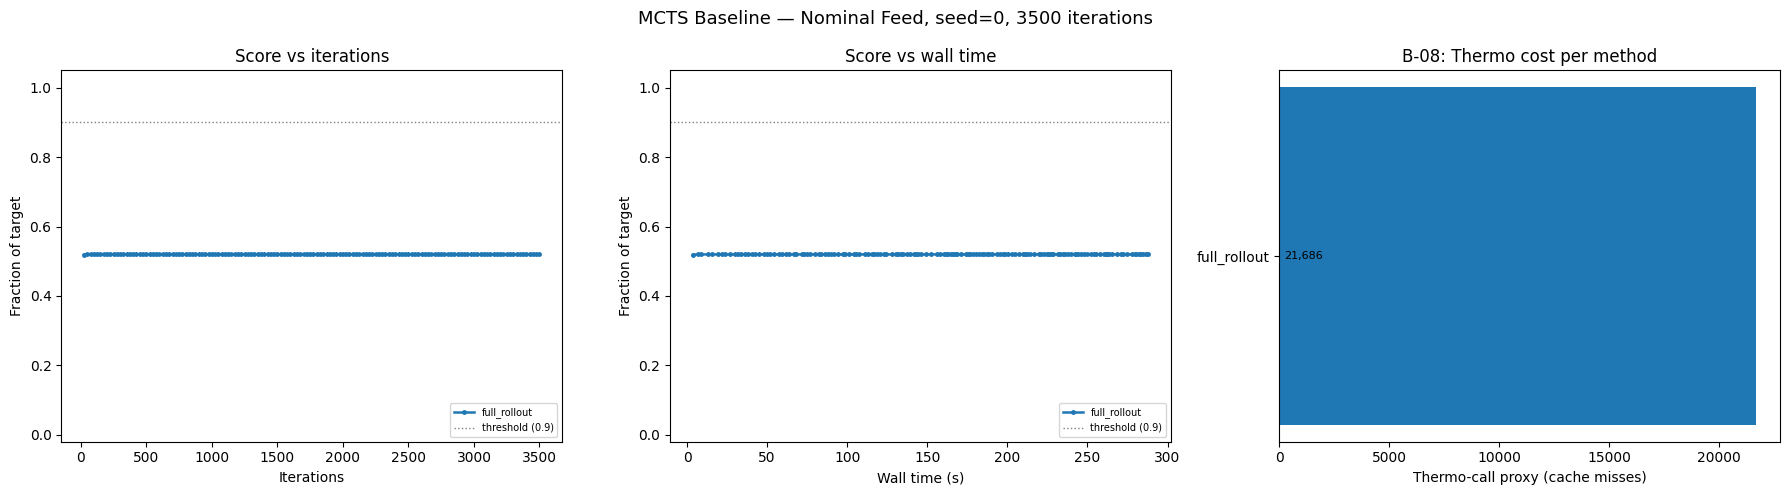

Saved: 00_progress_curves.png
Legend: dashed = Thompson Sampling  |  solid = UCT  |  same colour = same rollout type


In [14]:
# B-03: Anytime progress curves
# UCT methods  → solid lines.
# Thompson variants → dashed lines, same colour as UCT counterpart,
# so the selection-rule effect is visually isolated from rollout type.
BASE_COLORS = plt.cm.tab10.colors
UCT_METHODS = [
    'full_rollout', 'truncated_rollout', 'score_only',
    'original_s_plus_gamma_u', 'bounded_depth_aware', 'fug_gated',
]
THOMPSON_PAIR = {
    'thompson_full_rollout':      'full_rollout',
    'thompson_truncated_rollout': 'truncated_rollout',
}
method_colors = {name: BASE_COLORS[i] for i, name in enumerate(UCT_METHODS)}
for ts_name, uct_name in THOMPSON_PAIR.items():
    method_colors[ts_name] = method_colors[uct_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'MCTS Baseline — Nominal Feed, seed=0, {MCTS_ITERATIONS} iterations', fontsize=13)

for name, result in RESULTS.items():
    if not result.progress:
        continue
    iters = [int(r['iteration']) for r in result.progress]
    frac  = [float(r.get('fraction_of_target', 0.0)) for r in result.progress]
    secs  = [float(r['elapsed_s']) for r in result.progress]
    c  = method_colors.get(name, 'black')
    ls = '--' if name in THOMPSON_PAIR else '-'
    axes[0].plot(iters, frac, label=name, color=c, ls=ls, marker='o', markersize=2.5, lw=1.8)
    axes[1].plot(secs,  frac, label=name, color=c, ls=ls, marker='o', markersize=2.5, lw=1.8)

for ax in axes[:2]:
    ax.axhline(SUCCESS_THRESHOLD, ls=':', color='gray', lw=1,
               label=f'threshold ({SUCCESS_THRESHOLD})')
    ax.set_ylabel('Fraction of target')
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_xlabel('Iterations')
axes[0].set_title('Score vs iterations')
axes[1].set_xlabel('Wall time (s)')
axes[1].set_title('Score vs wall time')

# Thermo-proxy bar chart — hatching distinguishes Thompson from UCT
if TIMINGS:
    names_sorted = sorted(TIMINGS.keys(), key=lambda n: TIMINGS[n]['thermo_proxy'])
    proxies    = [TIMINGS[n]['thermo_proxy'] for n in names_sorted]
    bar_colors = [method_colors.get(n, 'black') for n in names_sorted]
    hatches    = ['//' if n in THOMPSON_PAIR else '' for n in names_sorted]
    bars = axes[2].barh(names_sorted, proxies, color=bar_colors)
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    axes[2].set_xlabel('Thermo-call proxy (cache misses)')
    axes[2].set_title('B-08: Thermo cost per method')
    for i, v in enumerate(proxies):
        axes[2].text(v * 0.01, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('00_progress_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: 00_progress_curves.png')
print('Legend: dashed = Thompson Sampling  |  solid = UCT  |  same colour = same rollout type')


In [15]:
# B-07: MCTSDiagnostics detail
print('=== B-07: MCTSDiagnostics per method ===\n')
for name in METHOD_NAMES:
    if name not in RESULTS:
        print(f'  [{name}] NOT RUN')
        continue
    d = RESULTS[name].diagnostics
    tp = d.n_apply_action_cache_misses + d.n_distillation_result_cache_misses
    print(f'  [{name}]')
    print(f'    Expanded nodes:           {d.n_expanded_nodes:7,}')
    print(f'    Duplicate states skipped: {d.n_duplicate_states_skipped:7,}  '
          f'({d.duplicate_skip_rate:.1%})')
    print(f'    Apply-action cache:       hits={d.n_apply_action_cache_hits:,}  '
          f'misses={d.n_apply_action_cache_misses:,}  '
          f'({d.apply_action_cache_hit_rate:.1%} hit rate)')
    print(f'    Distil-result cache:      hits={d.n_distillation_result_cache_hits:,}  '
          f'misses={d.n_distillation_result_cache_misses:,}  '
          f'({d.distillation_result_cache_hit_rate:.1%} hit rate)')
    print(f'    Thermo-proxy total:       {tp:7,}')
    print(f'    Valid-action calls:       {d.n_valid_action_calls:7,}  '
          f'(cache {d.valid_action_cache_hit_rate:.1%} hit rate)')
    if d.valid_actions_generated_by_kind:
        kinds_str = ', '.join(f'{k}={v}' for k, v in d.valid_actions_generated_by_kind)
        print(f'    Actions by kind:          {kinds_str}')
    print()

=== B-07: MCTSDiagnostics per method ===

  [full_rollout]
    Expanded nodes:             3,500
    Duplicate states skipped:       0  (0.0%)
    Apply-action cache:       hits=2,215  misses=10,423  (17.5% hit rate)
    Distil-result cache:      hits=5,060  misses=11,263  (31.0% hit rate)
    Thermo-proxy total:        21,686
    Valid-action calls:        12,640  (cache 30.4% hit rate)
    Actions by kind:          compressor=19670, distillation=4497, flash=2153, hx=55043, pump=12194, valve=20300



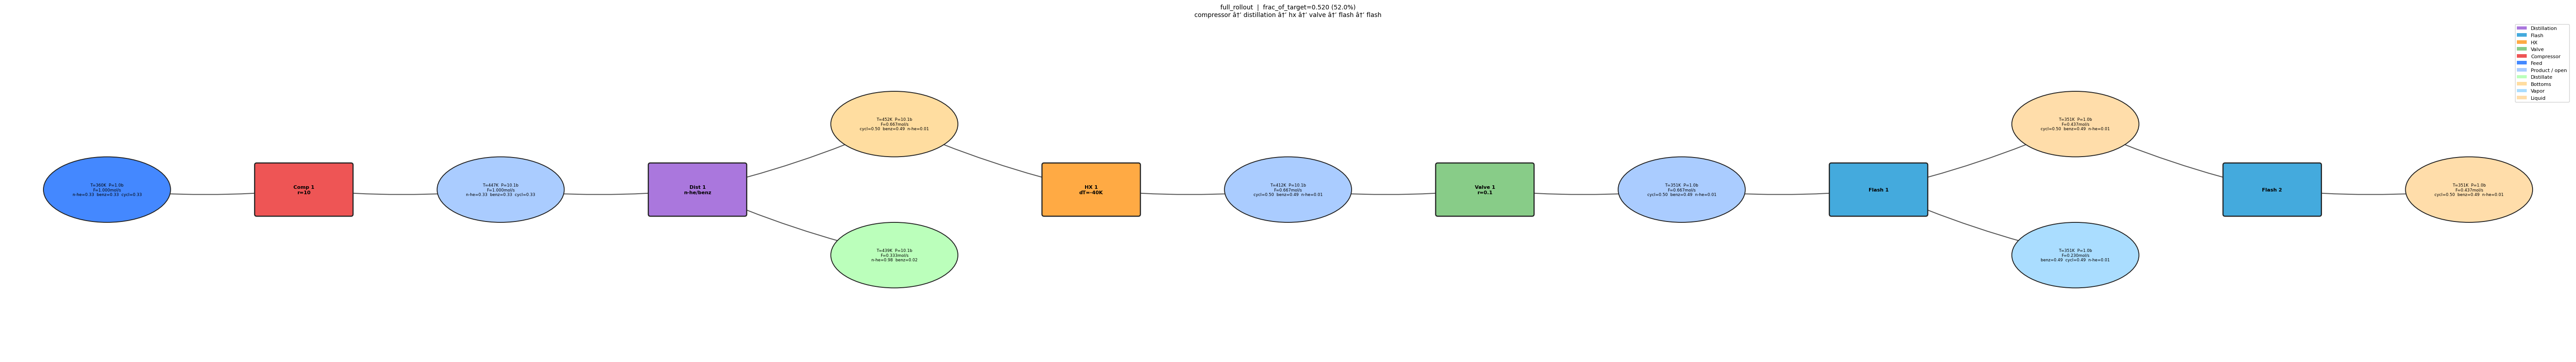

  Saved: 00_flowsheet_full_rollout.png


In [16]:
# B-05: Flowsheet visualization
# Scheme matches test_ml_5comp.ipynb:
#   - unit ops â†’ rounded coloured rectangles, labelled by type + index
#   - streams   â†’ ellipses coloured by role, showing T / P / F / top composition
#   - longest-path layer layout (left-to-right, no graphviz dependency)

import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

UNIT_COLORS = {
    'hx':           '#FFAA44',
    'valve':        '#88CC88',
    'flash':        '#44AADD',
    'distillation': '#AA77DD',
    'compressor':   '#EE5555',
    'pump':         '#5588EE',
    'recycle':      '#FF6644',
}
STREAM_COLORS = {
    'feed':        '#4488FF',
    'open':        '#AACCFF',
    'out':         '#AACCFF',
    'distillate':  '#BBFFBB',
    'bottoms':     '#FFDDA0',
    'vapor':       '#AADDFF',
    'liquid':      '#FFDDAA',
    'failed-open': '#FFAAAA',
}
RECYCLE_EDGE_COLOR = '#CC2200'
RECYCLE_FEED_COLOR = '#FF8800'

_COMP_SHORT = {
    'nitrogen': 'N2', 'methane': 'CH4', 'propane': 'C3',
    'n-butane': 'nC4', 'isobutane': 'iC4',
}

def _abbrev(c: str) -> str:
    return _COMP_SHORT.get(c, c[:4])


def _stream_node_label(stream_id: str, role: str, stream_data: dict) -> str:
    """Three-line label: T/P, F, top-3 composition."""
    d = stream_data.get(stream_id)
    if d is None:
        return role or stream_id[:10]
    T    = d['T_K']
    P_b  = d['P_Pa'] / 1e5
    F    = d['F_mol_s']
    comp = d['composition']
    top3 = sorted(comp.items(), key=lambda kv: -kv[1])[:3]
    comp_str = '  '.join(f'{_abbrev(c)}={v:.2f}' for c, v in top3 if v > 0.005)
    return f'T={T:.0f}K  P={P_b:.1f}b\nF={F:.3f}mol/s\n{comp_str}'


def _make_unit_labels(sequence) -> list:
    """Short human-readable labels: 'Dist 1\\nN2/CH4', 'HX 2\\ndT=+10K', â€¦"""
    kind_display = {
        'distillation': 'Dist', 'flash': 'Flash', 'hx': 'HX',
        'valve': 'Valve', 'compressor': 'Comp', 'pump': 'Pump',
    }
    counters: dict = {}
    labels = []
    for action in sequence:
        k = action.kind
        counters[k] = counters.get(k, 0) + 1
        n    = counters[k]
        name = kind_display.get(k, k.capitalize())
        line1 = f'{name} {n}'
        line2 = ''
        if k == 'distillation' and action.light_key and action.heavy_key:
            line2 = f'{_abbrev(action.light_key)}/{_abbrev(action.heavy_key)}'
        elif k == 'hx' and action.delta_T_K is not None:
            line2 = f'dT={action.delta_T_K:+.0f}K'
        elif k in ('valve', 'compressor', 'pump') and action.pressure_ratio is not None:
            line2 = f'r={action.pressure_ratio:.2g}'
        labels.append(f'{line1}\n{line2}' if line2 else line1)
    return labels


def draw_flowsheet(method_name: str) -> None:
    if method_name not in RESULTS:
        print(f'  {method_name}: no result available')
        return
    result = RESULTS[method_name]
    config = METHOD_CONFIGS[method_name]
    fot    = TIMINGS[method_name]['fraction_of_target']

    graph = mcts_replay_graph(
        feed_stream=FEED, provider=PROVIDER, config=config,
        sequence=result.best_sequence, components=COMPONENTS,
    )
    if graph.errors:
        print(f'  {method_name} replay errors: {graph.errors}')

    # --- Build stream data lookup (T, P, F, composition, role) ---
    stream_data: dict = {}
    sdf = graph.streams
    if hasattr(sdf, 'iterrows'):
        for _, row in sdf.iterrows():
            sid  = str(row['id'])
            comp = {c: float(row.get(f'x_{c}', 0.0)) for c in COMPONENTS}
            stream_data[sid] = {
                'T_K':       float(row['T_K']),
                'P_Pa':      float(row['P_Pa']),
                'F_mol_s':   float(row['F_mol_s']),
                'composition': comp,
                'role':      str(row.get('role', 'open')),
            }

    # --- Short labels for each action ---
    seq_labels = _make_unit_labels(result.best_sequence)

    # --- Parse edge DataFrame ---
    edge_rows = (graph.edges.to_dict('records')
                 if hasattr(graph.edges, 'to_dict') else list(graph.edges))
    USE_PG = bool(edge_rows) and 'source_kind' in edge_rows[0]

    # For process-graph format: map internal unit node IDs â†’ sequence index
    # (units appear as source in Uâ†’S edges in encounter order)
    unit_node_order: list = []
    for row in edge_rows:
        frm = str(row['from'])
        if str(row.get('source_kind', '')) == 'unit' and frm not in unit_node_order:
            unit_node_order.append(frm)
    unit_seq_idx = {nid: i for i, nid in enumerate(unit_node_order)}

    # --- Build networkx graph + per-node metadata ---
    G             = nx.DiGraph()
    node_type:    dict = {}
    node_color:   dict = {}
    node_label_d: dict = {}
    recycle_edges: set = set()

    def _register_stream(node_id: str, stream_id: str, role: str) -> None:
        if node_id in node_type:
            return
        node_type[node_id]    = 'stream'
        node_color[node_id]   = STREAM_COLORS.get(role, '#AACCFF')
        node_label_d[node_id] = _stream_node_label(stream_id, role, stream_data)

    def _register_unit(node_id: str, action_kind: str, seq_i) -> None:
        if node_id in node_type:
            return
        node_type[node_id]    = 'unit'
        node_color[node_id]   = UNIT_COLORS.get(action_kind, '#EEEEEE')
        node_label_d[node_id] = (seq_labels[seq_i]
                                 if seq_i is not None and seq_i < len(seq_labels)
                                 else action_kind)

    for row in edge_rows:
        frm, to   = str(row['from']), str(row['to'])
        edge_role = str(row.get('edge', ''))
        G.add_edge(frm, to)
        if edge_role == 'recycle':
            recycle_edges.add((frm, to))

        if USE_PG:
            sk     = str(row.get('source_kind', ''))
            tk     = str(row.get('target_kind', ''))
            frm_lb = str(row.get('from_label', frm))   # = stream.id for stream nodes
            to_lb  = str(row.get('to_label',   to))

            if sk == 'unit':
                i  = unit_seq_idx.get(frm)
                ak = result.best_sequence[i].kind if i is not None and i < len(result.best_sequence) else ''
                _register_unit(frm, ak, i)
            else:
                # stream as source of Sâ†’U edge; edge_role is "feed" here â€”
                # get the stream's actual role (distillate / bottoms / open â€¦)
                actual_role = stream_data.get(frm_lb, {}).get('role', 'open')
                _register_stream(frm, frm_lb, actual_role)

            if tk == 'unit':
                i  = unit_seq_idx.get(to)
                ak = result.best_sequence[i].kind if i is not None and i < len(result.best_sequence) else ''
                _register_unit(to, ak, i)
            else:
                # stream as target of Uâ†’S edge; edge_role IS the output role
                r = edge_role if edge_role in STREAM_COLORS else stream_data.get(to_lb, {}).get('role', 'open')
                _register_stream(to, to_lb, r)

        else:
            # Fallback format: from/to are stream IDs or "U{i:02d}" unit IDs
            ak = str(row.get('action_kind', ''))
            if edge_role == 'feed':   # stream â†’ unit
                r = stream_data.get(frm, {}).get('role', 'feed' if frm == FEED.id else 'open')
                _register_stream(frm, frm, r)
                try:
                    i = int(to.lstrip('U').lstrip('0') or '0') - 1
                except ValueError:
                    i = None
                ak_key = (result.best_sequence[i].kind
                          if i is not None and 0 <= i < len(result.best_sequence) else ak)
                _register_unit(to, ak_key, i)
                if ak == 'recycle':
                    recycle_edges.add((frm, to))
            else:                     # unit â†’ stream
                if frm not in node_type:
                    node_type[frm]    = 'unit'
                    node_color[frm]   = UNIT_COLORS.get(ak, '#EEEEEE')
                    node_label_d[frm] = ak
                r = edge_role if edge_role in STREAM_COLORS else 'open'
                _register_stream(to, to, r)

    # Recycle mixer feed edges (impure stream â†’ mixer, separate colour)
    mixer_nodes = {n for n in G.nodes()
                   if node_type.get(n) == 'unit'
                   and 'recycle' in node_label_d.get(n, '').lower()}
    recycle_feed_edges = {(f, t) for f, t in G.edges()
                          if t in mixer_nodes and (f, t) not in recycle_edges}

    # --- Longest-path layer assignment ---
    all_frm  = {str(r['from']) for r in edge_rows}
    all_to   = {str(r['to'])   for r in edge_rows}
    root_set = all_frm - all_to
    root     = next(iter(root_set)) if root_set else str(edge_rows[0]['from'])

    layers: dict = {root: 0}
    try:
        for node in nx.topological_sort(G):
            if node not in layers:
                layers[node] = 0
            for succ in G.successors(node):
                layers[succ] = max(layers.get(succ, 0), layers[node] + 1)
    except nx.NetworkXUnfeasible:
        queue = [root]
        while queue:
            nxt = []
            for n in queue:
                for nb in G.successors(n):
                    if nb not in layers:
                        layers[nb] = layers[n] + 1
                        nxt.append(nb)
            queue = nxt

    layer_groups: dict = {}
    for n, l in layers.items():
        layer_groups.setdefault(l, []).append(n)

    # --- Positions ---
    X_STEP, Y_STEP = 4.8, 3.2
    pos: dict = {}
    for layer, nodes in sorted(layer_groups.items()):
        n_nodes = len(nodes)
        for i, node in enumerate(sorted(nodes, key=lambda x: (node_type.get(x, ''), x))):
            pos[node] = (layer * X_STEP, (i - (n_nodes - 1) / 2.0) * Y_STEP)

    # --- Figure ---
    xs = [p[0] for p in pos.values()] or [0.0]
    ys = [p[1] for p in pos.values()] or [0.0]
    fig_w = max(14, max(xs) - min(xs) + 6)
    fig_h = max(7,  max(ys) - min(ys) + 5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    W_U, H_U = 2.3, 1.2   # unit rectangle
    W_S, H_S = 3.1, 1.6   # stream ellipse (wide enough for 3-line label)

    def _arrow(frm, to, color='#555555', lw=1.5, rad=0.05, ls='solid'):
        if frm not in pos or to not in pos:
            return
        ax.annotate('', xy=pos[to], xytext=pos[frm],
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                    connectionstyle=f'arc3,rad={rad}',
                                    linestyle=ls),
                    zorder=2)

    regular = [(f, t) for f, t in G.edges()
               if (f, t) not in recycle_edges and (f, t) not in recycle_feed_edges]
    for f, t in regular:
        _arrow(f, t)
    for f, t in recycle_edges:
        _arrow(f, t, color=RECYCLE_EDGE_COLOR, lw=2.0, rad=0.35, ls='dashed')
    for f, t in recycle_feed_edges:
        _arrow(f, t, color=RECYCLE_FEED_COLOR, lw=1.8, rad=0.20)

    for node in G.nodes():
        if node not in pos:
            continue
        x, y  = pos[node]
        color = node_color.get(node, '#DDDDDD')
        lbl   = node_label_d.get(node, node[:10])
        if node_type.get(node) == 'unit':
            ax.add_patch(mpatches.FancyBboxPatch(
                (x - W_U/2, y - H_U/2), W_U, H_U,
                boxstyle='round,pad=0.05',
                facecolor=color, edgecolor='#222222', linewidth=1.8, zorder=3))
            ax.text(x, y, lbl, ha='center', va='center',
                    fontsize=8, fontweight='bold', zorder=4)
        else:
            ax.add_patch(mpatches.Ellipse(
                (x, y), W_S, H_S,
                facecolor=color, edgecolor='#222222', linewidth=1.4, zorder=3))
            ax.text(x, y, lbl, ha='center', va='center', fontsize=6.5, zorder=4)

    margin = 2.5
    ax.set_xlim(min(xs) - margin, max(xs) + margin)
    ax.set_ylim(min(ys) - margin, max(ys) + margin)
    ax.set_aspect('equal')

    # Legend: only unit types actually used, all stream roles
    seen_kinds = {a.kind for a in result.best_sequence}
    legend_handles = []
    for kind, lbl in [('distillation', 'Distillation'), ('flash', 'Flash'),
                      ('hx', 'HX'), ('valve', 'Valve'),
                      ('compressor', 'Compressor'), ('pump', 'Pump'),
                      ('recycle', 'Recycle mixer')]:
        if kind in seen_kinds:
            legend_handles.append(mpatches.Patch(facecolor=UNIT_COLORS[kind], label=lbl))
    for role, lbl in [('feed', 'Feed'), ('open', 'Product / open'),
                      ('distillate', 'Distillate'), ('bottoms', 'Bottoms'),
                      ('vapor', 'Vapor'), ('liquid', 'Liquid')]:
        legend_handles.append(mpatches.Patch(facecolor=STREAM_COLORS[role], label=lbl))
    if recycle_edges:
        legend_handles += [
            mlines.Line2D([], [], color=RECYCLE_EDGE_COLOR, lw=2,
                          linestyle='dashed', label='Recycle stream'),
            mlines.Line2D([], [], color=RECYCLE_FEED_COLOR, lw=2, label='Feed augment'),
        ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8, framealpha=0.9)

    seq_str = ' â†’ '.join(a.kind for a in result.best_sequence)
    ax.set_title(
        f'{method_name}  |  frac_of_target={fot:.3f} ({fot*100:.1f}%)\n{seq_str}',
        fontsize=10, pad=8)

    plt.tight_layout()
    fname = f'00_flowsheet_{method_name}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')


for name in METHOD_NAMES:
    draw_flowsheet(name)

In [17]:
'''# B-10: Beta posterior visualization for all methods
# Each root child's Beta(1+V, 1+n-V) posterior is plotted.
# Thompson Sampling USED these posteriors for selection.
# UCT methods also accumulated the same statistics — plotting them shows
# the latent beliefs the search built even without explicitly sampling them.
#
# Narrow peak = many visits = high confidence.
# Wide curve  = few visits  = uncertain.
# Same colour scheme as progress curves (dashed = Thompson, solid = UCT).

from scipy.stats import beta as beta_dist

def _root_child_label(action) -> str:
    if action is None:
        return 'root'
    if action.kind == 'distillation':
        return f'{action.light_key[:3]}/{action.heavy_key[:3]}'
    if action.kind == 'hx':
        return f'hx({action.delta_T_K:+.0f}K)'
    if action.kind == 'flash':
        return 'flash'
    if action.kind in ('compressor', 'pump', 'valve'):
        ratio = action.pressure_ratio or '?'
        return f'{action.kind[:4]}(×{ratio})'
    return action.kind

methods_with_tree = [m for m in RESULTS if RESULTS[m].tree_root is not None]
n_methods = len(methods_with_tree)
if n_methods == 0:
    print('No tree roots available — re-run with return_tree=True.')
else:
    ncols = 2
    nrows = (n_methods + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if n_methods > 1 else [axes]

    x = np.linspace(0, 1, 400)

    for ax_idx, method in enumerate(methods_with_tree):
        ax = axes[ax_idx]
        root = RESULTS[method].tree_root
        children = sorted(root.children, key=lambda c: -c.visits)

        for child in children:
            if child.visits == 0:
                continue
            alpha = 1.0 + child.value
            beta_param = max(1e-6, 1.0 + child.visits - child.value)
            pdf = beta_dist.pdf(x, alpha, beta_param)
            label = f'{_root_child_label(child.action)}  n={child.visits}  Q={child.value/child.visits:.3f}'
            ls = '--' if 'thompson' in method else '-'
            ax.plot(x, pdf, label=label, lw=1.6, ls=ls)

        ax.axvline(root.value / max(root.visits, 1), color='gray', ls=':', lw=1,
                   label=f'root Q̄={root.value/max(root.visits,1):.3f}')
        ax.set_title(f'{method}  (root visits={root.visits})', fontsize=9)
        ax.set_xlabel('Expected reward')
        ax.set_ylabel('Posterior density')
        ax.legend(fontsize=7, loc='upper right')
        ax.set_xlim(0, 1)

    for ax in axes[n_methods:]:
        ax.set_visible(False)

    fig.suptitle('B-10: Beta posteriors at root — what the search learned about first splits',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('00_beta_posteriors.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: 00_beta_posteriors.png')
'''

"# B-10: Beta posterior visualization for all methods\n# Each root child's Beta(1+V, 1+n-V) posterior is plotted.\n# Thompson Sampling USED these posteriors for selection.\n# UCT methods also accumulated the same statistics — plotting them shows\n# the latent beliefs the search built even without explicitly sampling them.\n#\n# Narrow peak = many visits = high confidence.\n# Wide curve  = few visits  = uncertain.\n# Same colour scheme as progress curves (dashed = Thompson, solid = UCT).\n\nfrom scipy.stats import beta as beta_dist\n\ndef _root_child_label(action) -> str:\n    if action is None:\n        return 'root'\n    if action.kind == 'distillation':\n        return f'{action.light_key[:3]}/{action.heavy_key[:3]}'\n    if action.kind == 'hx':\n        return f'hx({action.delta_T_K:+.0f}K)'\n    if action.kind == 'flash':\n        return 'flash'\n    if action.kind in ('compressor', 'pump', 'valve'):\n        ratio = action.pressure_ratio or '?'\n        return f'{action.kind[:4]}(

In [18]:
# B-11: Intermediate streams and unit operations per method
# Shows all streams (products + any remaining open) and the full unit sequence.

from ml.mcts import _apply_action, SearchState as _SearchState


def _replay_dist_stages(method_name: str, result) -> dict[int, float]:
    """Replay the best sequence and return {step (1-based): theoretical_stages}
    for distillation steps only.  Caches are omitted — this is a one-off replay."""
    config = METHOD_CONFIGS[method_name]
    state = _SearchState(open_streams=(FEED,))
    stages: dict[int, float] = {}
    for step, action in enumerate(result.best_sequence, 1):
        prev = state.total_theoretical_stages
        state = _apply_action(state, action, PROVIDER, config)
        if action.kind == 'distillation':
            stages[step] = state.total_theoretical_stages - prev
    return stages


def _stream_rows(method_name, result):
    state = result.best_state
    rows = []
    all_streams = [(s, 'product') for s in (p.stream for p in state.products)]
    all_streams += [(s, 'open') for s in state.open_streams]
    for stream, role in all_streams:
        dominant = max(stream.composition, key=stream.composition.get) if stream.composition else '—'
        row = {
            'method': method_name,
            'stream_id': stream.id,
            'role': role,
            'T (K)': round(stream.temperature_K, 1),
            'P (bar)': round(stream.pressure_Pa / 1e5, 2),
            'F (mol/s)': round(stream.molar_flow_mols, 4),
            'dominant': dominant,
        }
        for comp in COMPONENTS:
            row[comp[:4]] = round(stream.composition.get(comp, 0.0), 4)
        rows.append(row)
    return rows


def _unit_rows(method_name, result):
    stages_map = _replay_dist_stages(method_name, result)
    rows = []
    for step, action in enumerate(result.best_sequence, 1):
        row = {
            'method': method_name,
            'step': step,
            'kind': action.kind,
            'stream': action.stream_id,
        }
        if action.kind == 'distillation':
            row['light_key'] = action.light_key
            row['heavy_key'] = action.heavy_key
            row['LK_rec'] = f'{action.light_key_recovery:.1%}' if action.light_key_recovery else '—'
            row['HK_rec'] = f'{action.heavy_key_recovery:.1%}' if action.heavy_key_recovery else '—'
            row['R/Rmin'] = f'{action.reflux_ratio_multiplier:.2f}' if action.reflux_ratio_multiplier is not None else '—'
            n = stages_map.get(step)
            row['N_stages'] = f'{n:.1f}' if n is not None and n > 0 else '—'
            row['param'] = '—'
        elif action.kind == 'hx':
            row['param'] = f'dT={action.delta_T_K:+.1f} K'
        elif action.kind in ('compressor', 'pump', 'valve'):
            row['param'] = f'ratio={action.pressure_ratio}' if action.pressure_ratio else f'dP={action.delta_P_Pa} Pa'
        else:
            row['param'] = '—'
        rows.append(row)
    return rows


print('=== B-11a: All streams (products + open) ===')
stream_rows = []
for name in RESULTS:
    stream_rows.extend(_stream_rows(name, RESULTS[name]))
stream_df = pd.DataFrame(stream_rows)
stream_df = stream_df.set_index(['method', 'stream_id'])
display(stream_df)

print()
print('=== B-11b: Unit operation sequence ===')
unit_rows = []
for name in RESULTS:
    unit_rows.extend(_unit_rows(name, RESULTS[name]))
unit_df = pd.DataFrame(unit_rows)
unit_df = unit_df.set_index(['method', 'step'])
unit_df = unit_df.fillna('—')
display(unit_df)


=== B-11a: All streams (products + open) ===


role  T (K)  \
method       stream_id                                                         
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...  open  438.7   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  open  351.4   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  open  351.4   

                                                                 P (bar)  \
method       stream_id                                                     
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...    10.13   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...     1.01   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...     1.01   

                                                                 F (mol/s)  \
method       stream_id                                                       
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...     0.3334   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...     0.2296   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...     0.4370   

                                                                    dominant  \
method       stream_id                                                         
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...     n-hexane   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...      benzene   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  cyclohexane   

                                                                   n-he  \
method       stream_id                                                    
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...  0.9799   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  0.0131   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  0.0084   

                                                                   benz  \
method       stream_id                                                    
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...  0.0200   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  0.4939   
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  0.4880   

                                                                   cycl  
method       stream_id                                                   
full_rollout Feed_comp_r10_1_dist_n-hexane_over_benzene_2_di...  0.0001  
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  0.4930  
             Feed_comp_r10_1_dist_n-hexane_over_benzene_2_bo...  0.5037


=== B-11b: Unit operation sequence ===


kind  \
method       step                 
full_rollout 1       compressor   
             2     distillation   
             3               hx   
             4            valve   
             5            flash   
             6            flash   

                                                              stream  \
method       step                                                      
full_rollout 1                                                  Feed   
             2                                       Feed_comp_r10_1   
             3     Feed_comp_r10_1_dist_n-hexane_over_benzene_2_b...   
             4     Feed_comp_r10_1_dist_n-hexane_over_benzene_2_b...   
             5     Feed_comp_r10_1_dist_n-hexane_over_benzene_2_b...   
             6     Feed_comp_r10_1_dist_n-hexane_over_benzene_2_b...   

                        param light_key heavy_key LK_rec HK_rec R/Rmin  \
method       step                                                        
full_rollout 1     ratio=10.0         —         —      —      —      —   
             2              —  n-hexane   benzene  98.0%   2.0%   1.30   
             3     dT=-40.0 K         —         —      —      —      —   
             4      ratio=0.1         —         —      —      —      —   
             5              —         —         —      —      —      —   
             6              —         —         —      —      —      —   

                  N_stages  
method       step           
full_rollout 1           —  
             2        87.4  
             3           —  
             4           —  
             5           —  
             6           —

In [19]:
rows = []

for method in methods_with_tree:
    root = RESULTS[method].tree_root
    children = sorted(root.children, key=lambda c: -c.visits)

    for child in children:
        if child.visits == 0:
            continue

        q = child.value / child.visits

        rows.append({
            "method": method,
            "label": _root_child_label(child.action),
            "n": child.visits,
            "value_sum": child.value,
            "Q": q,
            "alpha": 1.0 + child.value,
            "beta": 1.0 + child.visits - child.value,
        })

q_table = pd.DataFrame(rows)

q_table = q_table.sort_values(
    ["method", "n"],
    ascending=[True, False]
)

'''display(q_table.style.format({
    "Q": "{:.4f}",
    "value_sum": "{:.3f}",
    "alpha": "{:.3f}",
    "beta": "{:.3f}",
}))'''

for method, group in q_table.groupby("method", sort=False):
    root = RESULTS[method].tree_root
    root_q = root.value / max(root.visits, 1)

    print(f"\n{method}")
    print(f"root: n={root.visits}, Q̄_raw={root_q:.6g}")
    print("-" * 112)
    print(
        f"{'label':<18} "
        f"{'n':>7} "
        f"{'Q_raw':>16} "
        f"{'value_sum':>18} "
        f"{'alpha':>16} "
        f"{'beta':>16}"
    )
    print("-" * 112)

    for _, row in group.iterrows():
        print(
            f"{row['label']:<18} "
            f"{int(row['n']):>7} "
            f"{row['Q']:>16.6g} "
            f"{row['value_sum']:>18.6g} "
            f"{row['alpha']:>16.6g} "
            f"{row['beta']:>16.6g}"
        )

NameError: name 'methods_with_tree' is not defined

In [ ]:
# B-12: Tree traversal diagnostics -- training data quality per depth
#
# Shows per-method AND pooled statistics so that method-specific biases
# (e.g. Thompson visit concentration) are visible alongside the aggregate.

import math

def _traverse_tree(root, method_name):
    records = []
    queue = [(root, 0)]
    while queue:
        node, depth = queue.pop(0)
        if node.visits == 0:
            continue
        total_cv = sum(c.visits for c in node.children if c.visits > 0)
        if total_cv > 0:
            probs  = [c.visits / total_cv for c in node.children if c.visits > 0]
            h_raw  = -sum(p * math.log(p) for p in probs)
            h_norm = h_raw / math.log(len(probs)) if len(probs) > 1 else float("nan")
        else:
            h_norm = float("nan")
        records.append({
            "method":      method_name,
            "depth":       depth,
            "visits":      node.visits,
            "Q":           node.value / node.visits,
            "n_vis_ch":    sum(1 for c in node.children if c.visits > 0),
            "H_norm":      h_norm,
            "action_kind": node.action.kind if node.action else "root",
        })
        for child in node.children:
            queue.append((child, depth + 1))
    return records


# Collect
all_records = []
for name in METHOD_NAMES:
    if name not in RESULTS or RESULTS[name].tree_root is None:
        continue
    all_records.extend(_traverse_tree(RESULTS[name].tree_root, name))

tree_df = pd.DataFrame(all_records)

AGG = dict(
    n_nodes       = ("visits", "count"),
    median_visits = ("visits", "median"),
    mean_visits   = ("visits", "mean"),
    min_visits    = ("visits", "min"),
    max_visits    = ("visits", "max"),
    frac_n1       = ("visits", lambda x: (x == 1).mean()),
    std_Q         = ("Q",      "std"),
    mean_H_norm   = ("H_norm", lambda x: x.dropna().mean()),
    med_n_vis_ch  = ("n_vis_ch", "median"),
)

def _verdict(med, f1):
    if med >= 20 and f1 < 0.20:
        return "GOOD     tight target, reliable"
    elif med >= 5 and f1 < 0.50:
        return "MARGINAL use N_total weighting"
    else:
        return "POOR     single-visit dominant, exclude"

# -----------------------------------------------------------------------
# B-12a: Pooled per-depth statistics
# -----------------------------------------------------------------------
pooled = tree_df.groupby("depth").agg(**AGG).reset_index()

print("=== B-12a: Per-depth statistics -- POOLED across all methods ===")
print("frac_n1    : fraction of nodes visited exactly once (unreliable training target)")
print("std_Q      : spread of Q across nodes at this depth")
print("mean_H_norm: normalised policy entropy  (1=uniform  0=fully concentrated)")
print()
display(pooled.set_index("depth").round(3))

# -----------------------------------------------------------------------
# B-12b: Per-method per-depth statistics
# -----------------------------------------------------------------------
print()
print("=== B-12b: Per-depth statistics -- PER METHOD ===")
per_method = tree_df.groupby(["method", "depth"]).agg(**AGG).round(3)
display(per_method)

# -----------------------------------------------------------------------
# B-12c: Total visits per depth per method (visit-budget distribution)
# -----------------------------------------------------------------------
print()
print("=== B-12c: Total visits per depth per method ===")
visit_pivot = (
    tree_df.groupby(["method", "depth"])["visits"]
    .sum()
    .unstack(level="depth", fill_value=0)
)
display(visit_pivot)

# -----------------------------------------------------------------------
# B-12d: Action kind count per depth -- pooled and per method
# -----------------------------------------------------------------------
non_root = tree_df[tree_df["action_kind"] != "root"]

print()
print("=== B-12d: Action kind node count per depth -- POOLED ===")
kind_pooled = (
    non_root.groupby(["depth", "action_kind"]).size().unstack(fill_value=0)
)
display(kind_pooled)

print()
print("=== B-12d: Action kind node count per depth -- PER METHOD ===")
kind_per_method = (
    non_root.groupby(["method", "depth", "action_kind"]).size().unstack(fill_value=0)
)
display(kind_per_method)

# -----------------------------------------------------------------------
# B-12e: Training-data quality verdict -- pooled and per method
# -----------------------------------------------------------------------
print()
print("=== B-12e: Training-data quality verdict -- POOLED ===")
hdr = f"  {chr(39)+'depth'+chr(39):<6}  {chr(39)+'median_n'+chr(39):<10}  {chr(39)+'frac_n1'+chr(39):<8}  {chr(39)+'H_norm'+chr(39):<7}  verdict"
sep = "-" * 72
print(f"  {'depth':<6}  {'median_n':>9}  {'frac_n1':>8}  {'H_norm':>7}  verdict")
print(sep)
for _, row in pooled.iterrows():
    d   = int(row["depth"])
    med = row["median_visits"]
    f1  = row["frac_n1"]
    h   = row["mean_H_norm"]
    print(f"  {d:6d}  {med:9.1f}  {f1:8.3f}  {h:7.3f}  {_verdict(med, f1)}")

print()
print("=== B-12e: Training-data quality verdict -- PER METHOD ===")
methods_sorted = [m for m in METHOD_NAMES if m in RESULTS and RESULTS[m].tree_root is not None]
for name in methods_sorted:
    mdf = tree_df[tree_df["method"] == name]
    if mdf.empty:
        continue
    m_agg = mdf.groupby("depth").agg(**AGG).reset_index()
    print(f"  [{name}]")
    print(f"  {'depth':<6}  {'median_n':>9}  {'frac_n1':>8}  {'H_norm':>7}  verdict")
    print("  " + "-" * 68)
    for _, row in m_agg.iterrows():
        d   = int(row["depth"])
        med = row["median_visits"]
        f1  = row["frac_n1"]
        h   = row["mean_H_norm"]
        print(f"  {d:6d}  {med:9.1f}  {f1:8.3f}  {h:7.3f}  {_verdict(med, f1)}")
    print()


---

## B-09: Calibration Notes

After reviewing the timing table and progress curves above, adjust `config.py` as needed
before launching `01_batch_runner.ipynb`.

### `MCTS_ITERATIONS`
- If `full_rollout` takes **> 600 s** per run, reduce from 300 to 150 iterations.
- If all methods finish in **< 60 s**, 300 is fine; consider raising to 500 for the final study.

### `rollout_depth` for `truncated_rollout`
- If `truncated_rollout` and `score_only` show **identical** progress curves,
  increase `rollout_depth` from 3 to 5 in `config.py`.
- If `truncated_rollout` is substantially **slower** than `score_only` with no visible
  benefit, reduce to 1.

### `leaf_value_discount` (gamma) for `original_s_plus_gamma_u`
- Current: `None` (auto = N_C/2 = 2.5).
- If its progress curve **decreases** after iteration 150-200, gamma is too large.
  Reduce to 0.5 or 1.0 in `config.py` (see TODO T-03 and T-06).
- If it converges to the best score early, gamma is well-calibrated.

### Exploration weight
- Current `exploration_weight = 2.5` was calibrated on the 5-component system
  in `test_ml_5comp.ipynb`.
- If all methods saturate before iteration 150, test reducing to 1.4 in Notebook 05.

After any change to `config.py`, re-run Cells 1-11 before starting `01_batch_runner.ipynb`.